<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Import-libraries" data-toc-modified-id="Import-libraries-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Import libraries</a></span></li><li><span><a href="#Create-a-netCDF4.Dataset-object" data-toc-modified-id="Create-a-netCDF4.Dataset-object-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Create a netCDF4.Dataset object</a></span></li><li><span><a href="#Access-a-netCDF-variable" data-toc-modified-id="Access-a-netCDF-variable-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Access a netCDF variable</a></span></li><li><span><a href="#List-the-Dimensions" data-toc-modified-id="List-the-Dimensions-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>List the Dimensions</a></span></li><li><span><a href="#What-is-the-sea-surface-temperature-at-50N,-140E?" data-toc-modified-id="What-is-the-sea-surface-temperature-at-a-specific-location?-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>What is the sea surface temperature at a specific location?</a></span></li><li><span><a href="#Simple-visualization" data-toc-modified-id="Simple-visualization-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Simple visualization</a></span></li><li><span><a href="#Closing-your-netCDF-file" data-toc-modified-id="Closing-your-netCDF-file-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Closing your netCDF file</a></span></li></ul></div>

# Import libraries

In [2]:
# Check for netCDF4, install and restart kernel if necessary
import sys, importlib.util
from IPython import get_ipython
if importlib.util.find_spec('netCDF4') is None:
    !{sys.executable} -m pip install netCDF4
    get_ipython().kernel.do_shutdown(restart=True)
else:
     print(f'netCDF4 is already installed')

netCDF4 is already installed


In [1]:
import numpy as np
import pandas as pd
import netCDF4
import warnings
warnings.filterwarnings('ignore')

# Create a netCDF4.Dataset object

- **`f`** is an object, representing an open netCDF file.
- printing the object gives you summary information.
- the **`variables`** attribute of **`f`** is a dictionary containing netcdf variable objects.

In [2]:
f = netCDF4.Dataset('../data/tos_O1_2001-2002.nc', 'r')
print(f)

<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    title: IPSL  model output prepared for IPCC Fourth Assessment SRES A2 experiment
    institution: IPSL (Institut Pierre Simon Laplace, Paris, France)
    source: IPSL-CM4_v1 (2003) : atmosphere : LMDZ (IPSL-CM4_IPCC, 96x71x19) ; ocean ORCA2 (ipsl_cm4_v1_8, 2x2L31); sea ice LIM (ipsl_cm4_v
    contact: Sebastien Denvil, sebastien.denvil@ipsl.jussieu.fr
    project_id: IPCC Fourth Assessment
    table_id: Table O1 (13 November 2004)
    experiment_id: SRES A2 experiment
    realization: 1
    cmor_version: 0.96
    Conventions: CF-1.0
    history: YYYY/MM/JJ: data generated; YYYY/MM/JJ+1 data transformed  At 16:37:23 on 01/11/2005, CMOR rewrote data to comply with CF standards and IPCC Fourth Assessment requirements
    references: Dufresne et al, Journal of Climate, 2015, vol XX, p 136
    comment: Test drive
    dimensions(sizes): lon(180), lat(170), time(24), bnds(2)
    variables(dimensions): 

# Access a netCDF variable

- variable objects stored by name in **`variables`** dict.
- print the variable yields summary info (including all the attributes).
- no actual data read yet (just have a reference to the variable object with metadata).

In [3]:
print(f'Variables: {", ".join([names for names in f.variables])}\n')
print('Sea Surface Temperatur Variable:')
sea_surf_temp = f.variables['tos']  # sea surface temperature variable
print(sea_surf_temp)

Variables: lon, lon_bnds, lat, lat_bnds, time, time_bnds, tos

Sea Surface Temperatur Variable:
<class 'netCDF4.Variable'>
float32 tos(time, lat, lon)
    standard_name: sea_surface_temperature
    long_name: Sea Surface Temperature
    units: K
    cell_methods: time: mean (interval: 30 minutes)
    _FillValue: 1e+20
    missing_value: 1e+20
    original_name: sosstsst
    original_units: degC
    history:  At   16:37:23 on 01/11/2005: CMOR altered the data in the following ways: added 2.73150E+02 to yield output units;  Cyclical dimension was output starting at a different lon;
unlimited dimensions: time
current shape = (24, 170, 180)
filling on


# List the Dimensions

- All variables in a netCDF file have an associated shape, specified by a list of dimensions.
- Let's list all the dimensions in this netCDF file with their sizes:

In [4]:
dimensions = []
for dname, d in f.dimensions.items():
    dimensions.append({
        "Name":dname,
        "Size": d.size
    })
display(pd.DataFrame(dimensions))

,Name,Size
0,lon,180
1,lat,170
2,time,24
3,bnds,2


Each variable has a **`dimensions`**, **`shape`**, and **data type** attribute:

In [5]:
variables = []

for name, var in f.variables.items():
    variables.append({
        "Variable": name,
        "Dimensions": var.dimensions,
        "Shape": var.shape,
        "Data Type": str(var.dtype),
    })

pd.DataFrame(variables)

,Variable,Dimensions,Shape,Data Type
0,lon,"(lon,)","(180,)",float64
1,lon_bnds,"(lon, bnds)","(180, 2)",float64
2,lat,"(lat,)","(170,)",float64
3,lat_bnds,"(lat, bnds)","(170, 2)",float64
4,time,"(time,)","(24,)",float64
5,time_bnds,"(time, bnds)","(24, 2)",float64
6,tos,"(time, lat, lon)","(24, 170, 180)",float32


# What is the sea surface temperature at a specific location?

As an exercise, let's try to find the surface temperature at a specific location. First, let's build a functionn that returns this value:

In [17]:
def get_temperature(input_lat, input_lon):
    lat = f.variables['lat']
    lon = f.variables['lon']
    
    # extract lat/lon values (in degrees) to numpy arrays
    latvals = lat[:]
    lonvals = lon[:] 
    
    # get partial distances and find the closest point to the input on each dimension 
    lat_diff_sq = (latvals-input_lat)**2
    lon_diff_sq = (lonvals-input_lon)**2
    return int(np.argmin(lat_diff_sq)), int(np.argmin(lon_diff_sq))

Now, let's find the "distance between 50N and other latitude values, and 140E and other longitude values"

In [7]:
min_lat_idx, min_lon_idx = get_temperature(50, 140)
print(f'Indices closest to coordinates: ({min_lat_idx}, {min_lon_idx})')
print(f'Closest temperature reading at location: {sea_surf_temp[:].data[0, min_lat_idx, min_lon_idx]:.2}')

Indices closest to coordinates: (0, 0)
Closest temperature reading at location: 1e+20


1e+20 is the default value for locations on land. let's try 0N and 0E:

In [24]:
min_lat_idx, min_lon_idx = get_temperature(0, 0)
print(f'Indices closest to coordinates: ({min_lat_idx}, {min_lon_idx})')
print(f'Closest temperature reading at location: {sea_surf_temp[:].data[0, min_lat_idx, min_lon_idx]:.2f}')

Indices closest to coordinates: (79, 0)
Closest temperature reading at location: 302.42


# Simple visualization

Lastly, let's plot the surface temperature at a point in time:

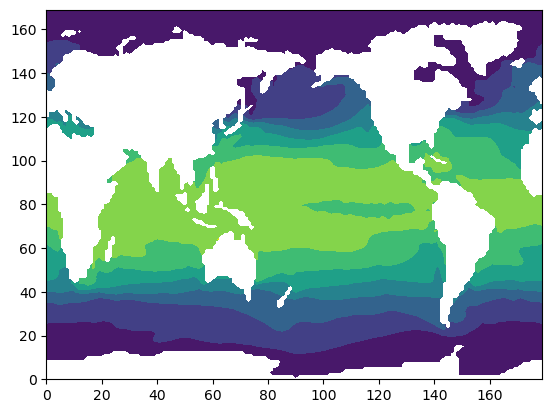

In [25]:
import matplotlib.pyplot as plt
cs = plt.contourf(sea_surf_temp[23,:,:])

# Closing your netCDF file

It's good to close netCDF files, but not actually necessary when Dataset is open for read access only.

In [31]:
f.close()